## Détermination des erreurs statistiques et systématiques

> Statistique de comptage

L'erreur statistque sur le taux de comptage $N_{J/\Psi}$ est donnée par la statistique poissonienne.

Soit $\lambda$ le nombre moyen de $J/\Psi$ produit sur un intevale de temps donné. Alors la probabilité de compter $k$ $J/\Psi$ dans cet intervalle de temps est:

$f(k,\lambda) = \frac{\lambda^k}{k!}e^{-\lambda}$

>Récap de la formule de la section efficace:

$\sigma_{J/\Psi} = \frac{N_{J/\Psi}^{cor}}{BR(J/\Psi \rightarrow l^+l^-)}\times \frac{\sigma_{MB}}{N_{MB}} $

Avec:

$N_{J/\Psi}^{cor} = N_{J\Psi}/\left< A \times \varepsilon \right>$ où $ \left< A \times \varepsilon \right> = 32.9\% $ en moyenne.

$BR(J/\Psi \rightarrow l^+l^-) =  (5.94 \pm 0.06)\%$ donc $\Delta BR(J/\Psi \rightarrow l^+l^-) = 0.06\%$

$\sigma_{MB} = 5̇7.52 \pm 0.03(\text{stat}) \pm 1.14(\text{syst}) \text{ mb}$ 

Ainsi en propageant sur le quotient, on trouve l'incertitude sur la section efficace:

$\Delta \sigma_{J/\Psi} = \sigma_{J/\Psi} \left( \frac{\Delta N_{J/\Psi}}{N_{J/\Psi}}+ \frac{\Delta BR(J/\Psi \rightarrow l^+l^-)}{BR(J/\Psi \rightarrow l^+l^-)} + \frac{\Delta \sigma_{MB} }{\sigma_{MB}} + \frac{\Delta N_{MB}}{N_{MB}}\right)$

> ébauche de code sur le calcul d'incertitude

In [72]:
import numpy as np
import scipy.stats as st

### définition des erreurs relatives ###
u_N = 0
u_BR = 0.06
u_sigma_mb = 0.03 + 1.14
u_N_mb = 0

### Initialisation des données ###
N = 0
BR = 5.94
sigma_mb = 57.52
N_mb = 0 


> 1) Calcul de l'intervale de confiance pour N

[4.75939605e+01 4.83341530e+04]


/tmp/ipykernel_205/708047784.py:6: RuntimeWarning: invalid value encountered in power
  return scale*(lamb**k/factorial(k))*np.exp(-lamb)
/tmp/ipykernel_205/708047784.py:6: RuntimeWarning: overflow encountered in exp
  return scale*(lamb**k/factorial(k))*np.exp(-lamb)


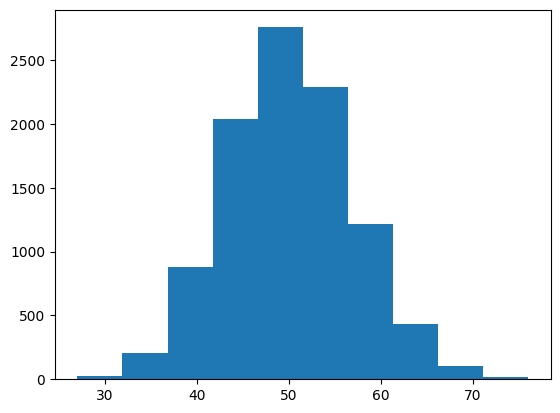

In [77]:
# Le but est de faire un fit d'une poissonienne sur la distribution du nombre N de JPSi sur un temps d'acquisition fixe
from scipy.special import factorial
        
#exemple avec une poissonienne toute faite
def poisson(k, lamb, scale):
    return scale*(lamb**k/factorial(k))*np.exp(-lamb)

Poiss = []
from random import randint
for i in range(0,100):
    for j in range(0,int(10000*poisson(i,50,1))):
        Poiss.append(i)
        
import matplotlib.pyplot as plt
counts, bins = np.histogram(Poiss)
plt.hist(Poiss,bins)

#Maintenant on fait un fit sur une poissonienne pour espérer retomber sur lambd
from scipy.optimize import curve_fit
parameters, matrice = curve_fit(poisson,bins[:-1],counts,p0=[60.,2.] )
print(parameters)

#notre lambda est donc parameters[0] 

###Calcul de l'intervalle de confiance à 95%###
def N_err_95(n,lambd):
    return 1.96*np.sqrt(lambd/n)

def IC_95(n,lambd):
    return (lambd - N_err_95;lambd+N_err_95) 


> Fonction finale pour l'err

In [ ]:
def pm(sigma_JPsi):
    return sigma_Jpsi*(u_N/N + u_BR/BR + u_sigma_mb/sigma_mb + u_N_mb/N_mb)